22050
stft shape=(4097, 41)


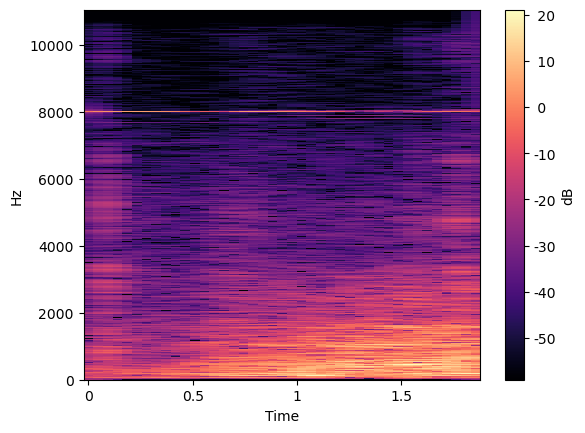

[2972 2972 2972 2972 2973 2973 2973 2973   65   72   61   61   61   49
   49   49   49   47   48   48   48   47   47   45   45   45   75   76
  173  173  173  173  168  169  168   62  172   75   75   69   69]
[7999.58496094 7999.58496094 7999.58496094 7999.58496094 8002.27661133
 8002.27661133 8002.27661133 8002.27661133  174.95727539  193.79882812
  164.19067383  164.19067383  164.19067383  131.89086914  131.89086914
  131.89086914  131.89086914  126.50756836  129.19921875  129.19921875
  129.19921875  126.50756836  126.50756836  121.12426758  121.12426758
  121.12426758  201.8737793   204.56542969  465.65551758  465.65551758
  465.65551758  465.65551758  452.19726562  454.88891602  452.19726562
  166.88232422  462.96386719  201.8737793   201.8737793   185.72387695
  185.72387695]
41


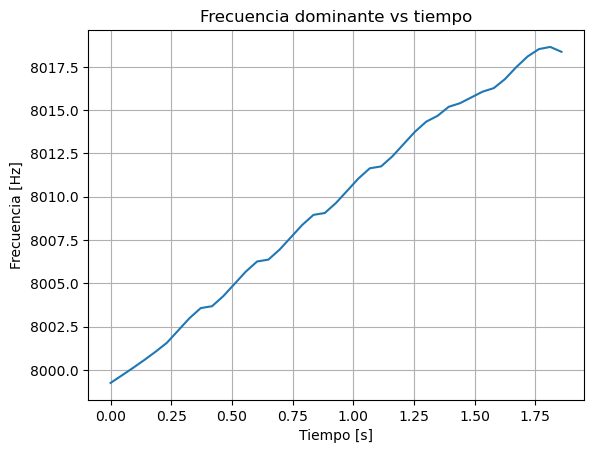

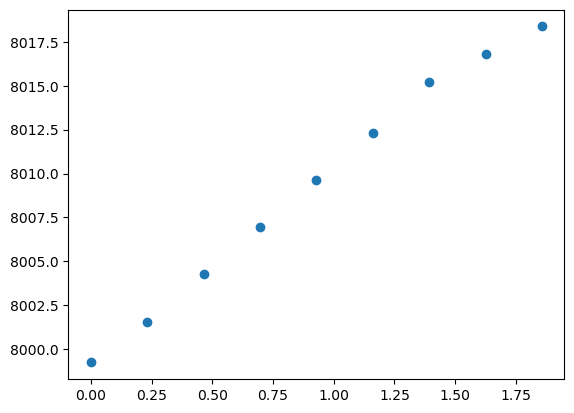

In [52]:
#código sacado en su mayoría desde https://github.com/librosa/librosa/blob/main/docs/tutorials/02-display/02-spectrogram.py,
#borré la mayor parte de comentarios en inglés. las partes hechas por mí tienen nombres y comentarios poco serios, pero respetenlo.
# %%
# .. _tutorial-display-spectrogram:
#
# Spectrograms
# ------------
# The :ref:`earlier sections <tutorial-intro-frequency>` of this tutorial demonstrate basic
# usage of the short-time Fourier transform (STFT), which can be useful for visualizing how
# the frequency content of a signal changes over time.
# This kind of visualization is known as a **spectrogram**, and you may have encountered
# this idea before.
# While spectrograms can be interpreted as *images* and displayed using `matplotlib`'s
# general-purpose image display functions (e.g. `matplotlib.pyplot.imshow`), there are several
# subtleties that can arise and it takes a bit of effort to get it right.
#
# As an example, let's create an STFT and display it using `imshow` directly.
# We'll first set up our imports and load an example file.

# sphinx_gallery_thumbnail_number = 6
from scipy.signal import medfilt, savgol_filter
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import HTML
ruta_acceso = r"C:\Users\A\OneDrive\Escritorio\tópicos\audios\prueba_inclinado_2.wav"
srr = 22050
hop_lengthh = 1024
y, sr = librosa.load(ruta_acceso, sr = srr, offset=1.4, duration = 1.9) #sr = None para aumentar las muestras
print(sr)
#Si la frecuencia de muestreo es 44 100 muestras por cada segundo, puedo despejar el tiempo para el cual el código calculará las frecuencias
#y usarlo para determinar el armónico más fuerte del espectro, haciendo (indice * hop_length)/tasa_muestreo
# %%
# Now we can compute the STFT, create a figure, and call `imshow`.
# Note that when we call `imshow`, we have to convert the `stft` array from complex to real, or
# else it will fail due to a type mismatch.
resolucion = 8192
stft = librosa.stft(y, hop_length = hop_lengthh, n_fft = resolucion)
print(f"stft shape={stft.shape}")
#fig, ax = plt.subplots()
#ax.imshow(np.abs(stft))
#esta parte la hice yo, quizas se puede hacer más rápido con numpy pero usé lo que sabía perdoneme profe
t= np.zeros(stft.shape[1])
for i in range(0, stft.shape[1]):
    t[i] = (i*hop_lengthh)/srr    

#fig, ax = plt.subplots()
#librosa.display.specshow(stft, x_axis="time", y_axis="hz", vscale="dB")
fig, ax = plt.subplots()
img = librosa.display.specshow(stft, x_axis="time", y_axis="hz", vscale="dB", sr=srr, hop_length = hop_lengthh)
librosa.display.colorbar_db(img)
plt.savefig("espectrograma_carrito_i1.pdf")
plt.show()
frecuencias = librosa.fft_frequencies(sr=srr, n_fft=resolucion)
frecuencias_absolutas = np.abs(stft) #por si acaso? me dijeron que lo haga
#ahora voy a filtrar un rango de frecuencia
frecuencias_filtradas = []
indices_frecuencias_filtradas = []
amplitudes_filtradas = []

for i in range(0, len(frecuencias)):
    if frecuencias[i]>=7900 and frecuencias[i]<=8100:
        frecuencias_filtradas.append(frecuencias[i])
        amplitudes_filtradas.append(frecuencias_absolutas[i, :])
        
#paso las listas a arreglos numpy para trabajarlos más fácil y que me compile el codigo
frecuencias_filtradas = np.array(frecuencias_filtradas)
amplitudes_filtradas = np.array(amplitudes_filtradas)
indices_frecuencias_filtradas = np.argmax(amplitudes_filtradas, axis=0)
f_dominante = frecuencias_filtradas[indices_frecuencias_filtradas]

f_dominante_promedio = medfilt(f_dominante, kernel_size=7) #esto lo hice con IA, se supone que filtra el ruido
indices_f_max = np.argmax(frecuencias_absolutas, axis=0) 
print(indices_f_max) #no muestra todos los indices pero elijo confiar? el np.argmax sin el axis=0 me devuelve un único valor (imagino que de todo el audio)
#esta parte si funciona pero hay código que no usamos realmente, son vestigios de codigos anteriores
no_se_si_funciona = frecuencias[indices_f_max]
print(no_se_si_funciona)

#un ajuste lineal para que los gráficos no se vean no continuos
f_continua = savgol_filter(f_dominante_promedio, window_length=11, polyorder=3) #esto lo hice con IA


largo_f_continua = len(f_continua)
print(largo_f_continua)

#extraigo una muestra para no graficar como 200 puntos de velocidad, la muestra ES representativa porque pasó por promedios y ajustes
f_continua_muestra = f_continua[0:largo_f_continua:5]
t_f_continua_muestra = t[0:largo_f_continua:5]


plt.plot(t, f_continua)
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia [Hz]")
plt.grid(True)
plt.title("Frecuencia dominante vs tiempo")
plt.savefig("Frecuencia_dominante_carritoi1.pdf")
plt.show()

plt.scatter(t_f_continua_muestra, f_continua_muestra)
plt.show()



#plt.plot(t_f_dom, f_dominante)
#plt.show()
#Ahora nos falta separar los gráficos y hacer una máscara AYUDAAAAAAA




#fig, ax = plt.subplots()
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB")
#librosa.display.colorbar_db(img)


#fig, ax = plt.subplots(nrows=2, sharex=True, height_ratios=[4, 1])
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB", ax=ax[0])
#librosa.display.colorbar_db(img)


#ax[0].legend(loc="upper right")
#ax[0].label_outer("ola")
#librosa.display.waveshow(y=y, sr=sr, ax=ax[1])



# Use the native sampling rate of the example by setting sr=None
#y, sr = librosa.loadx(ruta_acceso, sr=None)

# Use larger frames (4096 samples) to account for the higher sampling rate
# Use a smaller hop length to get a higher time resolution in the stft
#stft = librosa.stft(y, n_fft=8192, hop_length=256)
#print(f"stft shape={stft.shape}")

# %%
# Now we can supply our analysis parameters to `specshow` so that axes are constructed
# properly.
# While we're at it, we can also change the threshold for decibel scaling by setting `top_db`
# (which defaults to 80, but let's set it to 60 to suppress low-amplitude noise).
# Finally, we can choose a different colormap for sequential data by setting `cmap_seq=`.
# Here we'll use a black-on-white colormap, suitable for print media.

#fig, ax = plt.subplots()
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB",
                              # sr=sr, hop_length=256, top_db=60,
                               #cmap_seq="gray_r")
#librosa.display.colorbar_db(img)

# %%
# Summary and tips
# ----------------
# We've really only scratched the surface when it comes to the functionality provided by
# `specshow`, and the subsequent sections in this tutorial will dig into the details.
#
# A few things that can be helpful to keep in mind:
#   - The most important parameters are `x_axis` and `y_axis`.  Most of the remaining
#     parameters are there to support unit conversion for different axis scalings.
#   - There is nothing special about the orientation here: any axis can be a time axis or a
#     frequency axis.  This makes it easy to draw sideways spectrograms, time-by-time plots,
#     frequency-by-frequency plots, etc.  The section on :ref:`non-spectral <tutorial-display-nonspectral>`
#     data visualization provides some examples of this.
#   - The underlying display object is generated by `matplotlib.pyplot.pcolormesh`.  Any
#     parameters acceptable to `pcolormesh` can be passed into `specshow` as well.





In [53]:
#Esta celda es para calcular la desviación estándar de una prueba en reposo
import numpy as np
import librosa
from scipy.signal import medfilt, savgol_filter

# 1. Cargar el audio en reposo (cambia la ruta a tu archivo de calibración)
ruta_reposo = r"C:\Users\A\OneDrive\Escritorio\tópicos\audios\prueba_sonido (1).wav"
srr = 17000
hop_lengthh = 1024
resolucion = 16384

y_reposo, sr_reposo = librosa.load(ruta_reposo, sr=srr, offset=1.0)

stft_reposo = librosa.stft(y_reposo, hop_length=hop_lengthh, n_fft=resolucion)
frecuencias_absolutas_reposo = np.abs(stft_reposo)
frecuencias = librosa.fft_frequencies(sr=srr, n_fft=resolucion)

frecuencias_filtradas_rep = []
amplitudes_filtradas_rep = []

for i in range(0, len(frecuencias)):
    if frecuencias[i] >= 7800 and frecuencias[i] <= 8200:
        frecuencias_filtradas_rep.append(frecuencias[i])
        amplitudes_filtradas_rep.append(frecuencias_absolutas_reposo[i, :])

frecuencias_filtradas_rep = np.array(frecuencias_filtradas_rep)
amplitudes_filtradas_rep = np.array(amplitudes_filtradas_rep)

indices_frecuencias_filtradas_rep = np.argmax(amplitudes_filtradas_rep, axis=0)
f_dominante_reposo = frecuencias_filtradas_rep[indices_frecuencias_filtradas_rep]


f_dominante_promedio_rep = medfilt(f_dominante_reposo, kernel_size=7)
f_continua_reposo = savgol_filter(f_dominante_promedio_rep, window_length=21, polyorder=3)

# calculo la desviación estándar al rededor del valor 8000, que uso para despejar la velocidad
error_f_rep = np.sqrt(np.mean((f_continua_reposo - 8000)**2))
print(error_f_rep)

1.813975503277103


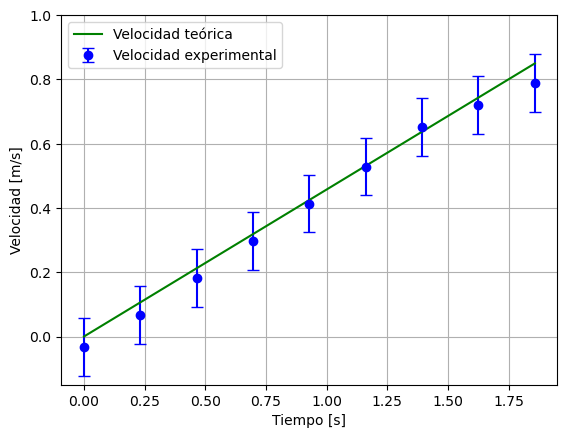

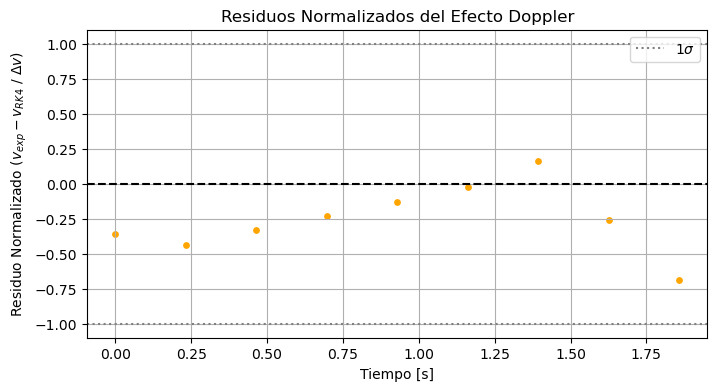

In [54]:
#Ahora programo las formulas del efecto doppler
h_1 = 0.097
h_2 = 0.175
Largo = 2.08
g=9.81

T = 273.15+20.1 
V_sonido = np.sqrt((1.4*8.314*T)/0.029)
f_emitida = 8000
velocidades_receptor = np.zeros(len(f_continua_muestra))
for i in range(len(f_continua_muestra)):
    v_r = V_sonido*((f_continua_muestra/f_emitida)-1) #porque es un arreglo de numpy (debería funcionar)


velocidad_teórica = t_f_continua_muestra*(h_1/Largo)*g

#análisis de error propagado en la velocidad
import numpy as np
error_termometro = 1
error_Hz_recibido = srr/resolucion
dv_vs = (f_continua_muestra/f_emitida)-1
dv_fr = V_sonido*(1/f_emitida)
dv_fe = V_sonido*(-(f_continua_muestra/f_emitida**2))
error_v_sonido = 0.5*np.abs((1/(np.sqrt(T)))*np.sqrt(1.4*8.314/0.029))*error_termometro
error_velocidad = np.sqrt((dv_vs*error_v_sonido)**2+(dv_fr*error_Hz_recibido)**2+(dv_fe*error_f_rep)**2) 

#residuos normalizados 

residuos_normalizados = (v_r-velocidad_teórica)/error_velocidad
plt.errorbar(t_f_continua_muestra, v_r, yerr=error_velocidad, fmt="o", capsize =4, color="blue", label="Velocidad experimental")
plt.plot(t_f_continua_muestra, velocidad_teórica, color="green", label="Velocidad teórica")
plt.ylim((-0.15, 1.0))
plt.ylabel("Velocidad [m/s]")
plt.xlabel("Tiempo [s]")
plt.grid(True)
plt.legend()
plt.savefig("Comparacion_Velocidaf_carritoi1.pdf")
plt.show()

plt.figure(figsize=(8, 4))
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='gray', linestyle=':', label=r'$1\sigma$')
plt.axhline(-1, color='gray', linestyle=':')

plt.scatter(t_f_continua_muestra, residuos_normalizados, color='orange', s=15)
plt.xlabel("Tiempo [s]")
plt.ylabel(r"Residuo Normalizado ($v_{exp} - v_{RK4}$ / $\Delta v$)")
plt.title("Residuos Normalizados del Efecto Doppler")
plt.legend()
plt.grid(True)
plt.savefig("ResiduosN_carritoi1.pdf")

plt.show()

22050
stft shape=(4097, 24)


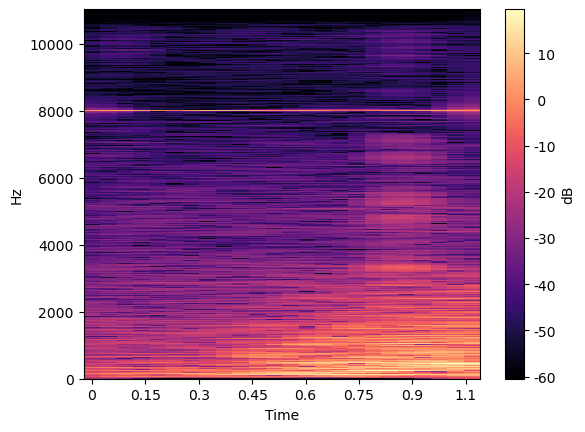

[2972 2972   41   41   41   57   56   56   53   52   52   52   52   60
   60   47   46   91  170  170  152  168  168  168]
[7999.58496094 7999.58496094  110.35766602  110.35766602  110.35766602
  153.42407227  150.73242188  150.73242188  142.6574707   139.96582031
  139.96582031  139.96582031  139.96582031  161.49902344  161.49902344
  126.50756836  123.81591797  244.94018555  457.58056641  457.58056641
  409.13085938  452.19726562  452.19726562  452.19726562]
24


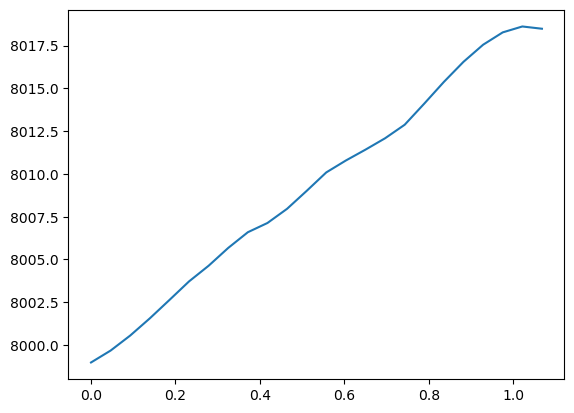

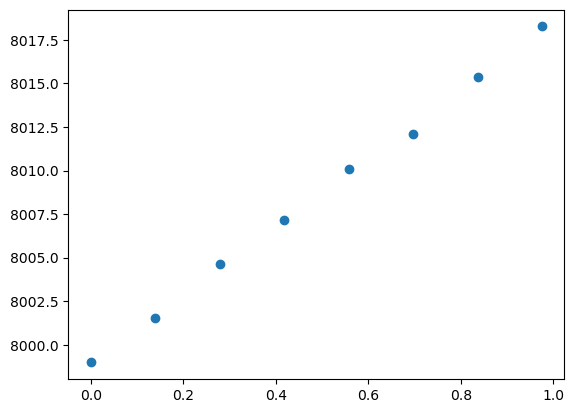

In [55]:
#código sacado en su mayoría desde https://github.com/librosa/librosa/blob/main/docs/tutorials/02-display/02-spectrogram.py,
#borré la mayor parte de comentarios en inglés. las partes hechas por mí tienen nombres y comentarios poco serios, pero respetenlo.
# %%
# .. _tutorial-display-spectrogram:
#
# Spectrograms
# ------------
# The :ref:`earlier sections <tutorial-intro-frequency>` of this tutorial demonstrate basic
# usage of the short-time Fourier transform (STFT), which can be useful for visualizing how
# the frequency content of a signal changes over time.
# This kind of visualization is known as a **spectrogram**, and you may have encountered
# this idea before.
# While spectrograms can be interpreted as *images* and displayed using `matplotlib`'s
# general-purpose image display functions (e.g. `matplotlib.pyplot.imshow`), there are several
# subtleties that can arise and it takes a bit of effort to get it right.
#
# As an example, let's create an STFT and display it using `imshow` directly.
# We'll first set up our imports and load an example file.

# sphinx_gallery_thumbnail_number = 6
from scipy.signal import medfilt, savgol_filter
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import HTML
ruta_acceso = r"C:\Users\A\OneDrive\Escritorio\tópicos\audios\prueba2_inclinado2.wav"
srr = 22050
hop_lengthh = 1024
y, sr = librosa.load(ruta_acceso, sr = srr, offset=1.6, duration = 1.09) #sr = None para aumentar las muestras
print(sr)
#Si la frecuencia de muestreo es 44 100 muestras por cada segundo, puedo despejar el tiempo para el cual el código calculará las frecuencias
#y usarlo para determinar el armónico más fuerte del espectro, haciendo (indice * hop_length)/tasa_muestreo
# %%
# Now we can compute the STFT, create a figure, and call `imshow`.
# Note that when we call `imshow`, we have to convert the `stft` array from complex to real, or
# else it will fail due to a type mismatch.
resolucion = 8192
stft = librosa.stft(y, hop_length = hop_lengthh, n_fft = resolucion)
print(f"stft shape={stft.shape}")
#fig, ax = plt.subplots()
#ax.imshow(np.abs(stft))
#esta parte la hice yo, quizas se puede hacer más rápido con numpy pero usé lo que sabía perdoneme profe
t= np.zeros(stft.shape[1])
for i in range(0, stft.shape[1]):
    t[i] = (i*hop_lengthh)/srr    

#fig, ax = plt.subplots()
#librosa.display.specshow(stft, x_axis="time", y_axis="hz", vscale="dB")
fig, ax = plt.subplots()
img = librosa.display.specshow(stft, x_axis="time", y_axis="hz", vscale="dB", sr=srr, hop_length = hop_lengthh)
librosa.display.colorbar_db(img)
plt.show()
frecuencias = librosa.fft_frequencies(sr=srr, n_fft=resolucion)
frecuencias_absolutas = np.abs(stft) #por si acaso? me dijeron que lo haga
#ahora voy a filtrar un rango de frecuencia
frecuencias_filtradas = []
indices_frecuencias_filtradas = []
amplitudes_filtradas = []

for i in range(0, len(frecuencias)):
    if frecuencias[i]>=7900 and frecuencias[i]<=8100:
        frecuencias_filtradas.append(frecuencias[i])
        amplitudes_filtradas.append(frecuencias_absolutas[i, :])
        
#paso las listas a arreglos numpy para trabajarlos más fácil y que me compile el codigo
frecuencias_filtradas = np.array(frecuencias_filtradas)
amplitudes_filtradas = np.array(amplitudes_filtradas)
indices_frecuencias_filtradas = np.argmax(amplitudes_filtradas, axis=0)
f_dominante = frecuencias_filtradas[indices_frecuencias_filtradas]

f_dominante_promedio = medfilt(f_dominante, kernel_size=7) #esto lo hice con IA, se supone que filtra el ruido
indices_f_max = np.argmax(frecuencias_absolutas, axis=0) 
print(indices_f_max) #no muestra todos los indices pero elijo confiar? el np.argmax sin el axis=0 me devuelve un único valor (imagino que de todo el audio)
#esta parte si funciona pero hay código que no usamos realmente, son vestigios de codigos anteriores
no_se_si_funciona = frecuencias[indices_f_max]
print(no_se_si_funciona)

#un ajuste lineal para que los gráficos no se vean no continuos
f_continua = savgol_filter(f_dominante_promedio, window_length=11, polyorder=3) #esto lo hice con IA


largo_f_continua = len(f_continua)
print(largo_f_continua)

#extraigo una muestra para no graficar como 200 puntos de velocidad, la muestra ES representativa porque pasó por promedios y ajustes
f_continua_muestra = f_continua[0:largo_f_continua:3]
t_f_continua_muestra = t[0:largo_f_continua:3]


plt.plot(t, f_continua)
plt.show()

plt.scatter(t_f_continua_muestra, f_continua_muestra)
plt.show()



#plt.plot(t_f_dom, f_dominante)
#plt.show()
#Ahora nos falta separar los gráficos y hacer una máscara AYUDAAAAAAA




#fig, ax = plt.subplots()
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB")
#librosa.display.colorbar_db(img)


#fig, ax = plt.subplots(nrows=2, sharex=True, height_ratios=[4, 1])
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB", ax=ax[0])
#librosa.display.colorbar_db(img)


#ax[0].legend(loc="upper right")
#ax[0].label_outer("ola")
#librosa.display.waveshow(y=y, sr=sr, ax=ax[1])



# Use the native sampling rate of the example by setting sr=None
#y, sr = librosa.loadx(ruta_acceso, sr=None)

# Use larger frames (4096 samples) to account for the higher sampling rate
# Use a smaller hop length to get a higher time resolution in the stft
#stft = librosa.stft(y, n_fft=8192, hop_length=256)
#print(f"stft shape={stft.shape}")

# %%
# Now we can supply our analysis parameters to `specshow` so that axes are constructed
# properly.
# While we're at it, we can also change the threshold for decibel scaling by setting `top_db`
# (which defaults to 80, but let's set it to 60 to suppress low-amplitude noise).
# Finally, we can choose a different colormap for sequential data by setting `cmap_seq=`.
# Here we'll use a black-on-white colormap, suitable for print media.

#fig, ax = plt.subplots()
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB",
                              # sr=sr, hop_length=256, top_db=60,
                               #cmap_seq="gray_r")
#librosa.display.colorbar_db(img)

# %%
# Summary and tips
# ----------------
# We've really only scratched the surface when it comes to the functionality provided by
# `specshow`, and the subsequent sections in this tutorial will dig into the details.
#
# A few things that can be helpful to keep in mind:
#   - The most important parameters are `x_axis` and `y_axis`.  Most of the remaining
#     parameters are there to support unit conversion for different axis scalings.
#   - There is nothing special about the orientation here: any axis can be a time axis or a
#     frequency axis.  This makes it easy to draw sideways spectrograms, time-by-time plots,
#     frequency-by-frequency plots, etc.  The section on :ref:`non-spectral <tutorial-display-nonspectral>`
#     data visualization provides some examples of this.
#   - The underlying display object is generated by `matplotlib.pyplot.pcolormesh`.  Any
#     parameters acceptable to `pcolormesh` can be passed into `specshow` as well.





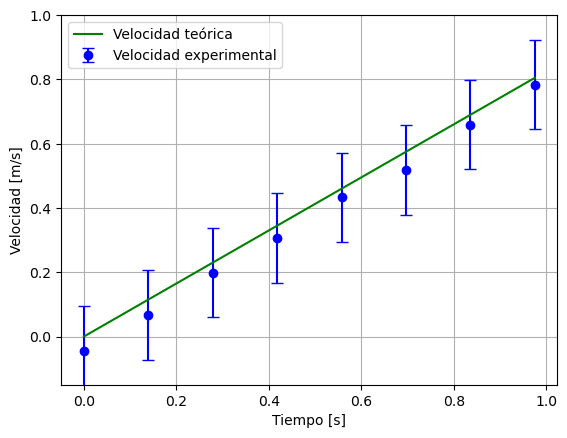

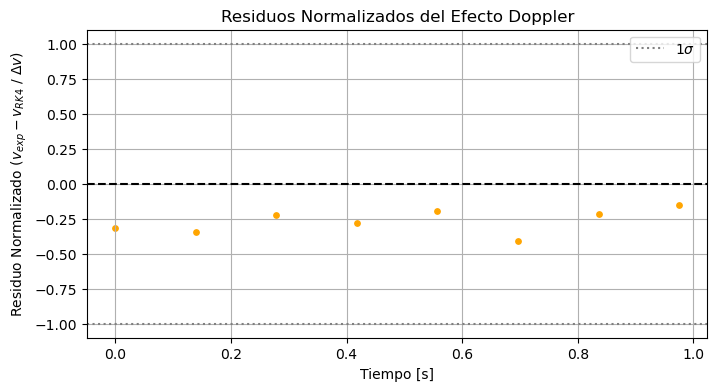

In [56]:
#Ahora programo las formulas del efecto doppler
h_1 = 0.097
h_2 = 0.175
Largo = 2.08
g=9.81

T = 273.15+20.1 
V_sonido = np.sqrt((1.4*8.314*T)/0.029)
f_emitida = 8000
velocidades_receptor = np.zeros(len(f_continua_muestra))
for i in range(len(f_continua_muestra)):
    v_r = V_sonido*((f_continua_muestra/f_emitida)-1) #porque es un arreglo de numpy (debería funcionar)


velocidad_teórica = t_f_continua_muestra*(h_2/Largo)*g

#análisis de error propagado en la velocidad
import numpy as np
error_termometro = 1
error_Hz_recibido = srr/resolucion
dv_vs = (f_continua_muestra/f_emitida)-1
dv_fr = V_sonido*(1/f_emitida)
dv_fe = V_sonido*(-(f_continua_muestra/f_emitida**2))
error_v_sonido = 0.5*np.abs((1/(np.sqrt(T)))*np.sqrt(1.4*8.314/0.029))*error_termometro
error_velocidad = np.sqrt((dv_vs*error_v_sonido)**2+(dv_fr*error_Hz_recibido)**2+(dv_fe*error_f_rep)**2) 

#residuos normalizados 

residuos_normalizados = (v_r-velocidad_teórica)/error_velocidad
plt.errorbar(t_f_continua_muestra, v_r, yerr=error_velocidad, fmt="o", capsize =4, color="blue", label="Velocidad experimental")
plt.plot(t_f_continua_muestra, velocidad_teórica, color="green", label="Velocidad teórica")
plt.ylim((-0.15, 1.0))
plt.ylabel("Velocidad [m/s]")
plt.xlabel("Tiempo [s]")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='gray', linestyle=':', label=r'$1\sigma$')
plt.axhline(-1, color='gray', linestyle=':')

plt.scatter(t_f_continua_muestra, residuos_normalizados, color='orange', s=15)
plt.xlabel("Tiempo [s]")
plt.ylabel(r"Residuo Normalizado ($v_{exp} - v_{RK4}$ / $\Delta v$)")
plt.title("Residuos Normalizados del Efecto Doppler")
plt.legend()
plt.grid(True)
plt.show()

22050
stft shape=(4097, 35)


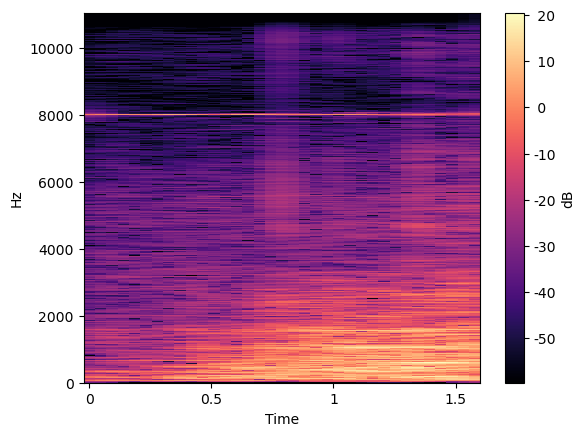

[ 41  41  41  41  41  41  41  49  48  49  49  49  58  58  59  59  60  60
 171 171 172 153 172 169 169  54  55  55 243 164 224 224 224 227 371]
[110.35766602 110.35766602 110.35766602 110.35766602 110.35766602
 110.35766602 110.35766602 131.89086914 129.19921875 131.89086914
 131.89086914 131.89086914 156.11572266 156.11572266 158.80737305
 158.80737305 161.49902344 161.49902344 460.2722168  460.2722168
 462.96386719 411.82250977 462.96386719 454.88891602 454.88891602
 145.34912109 148.04077148 148.04077148 654.07104492 441.43066406
 602.9296875  602.9296875  602.9296875  611.00463867 998.60229492]
35


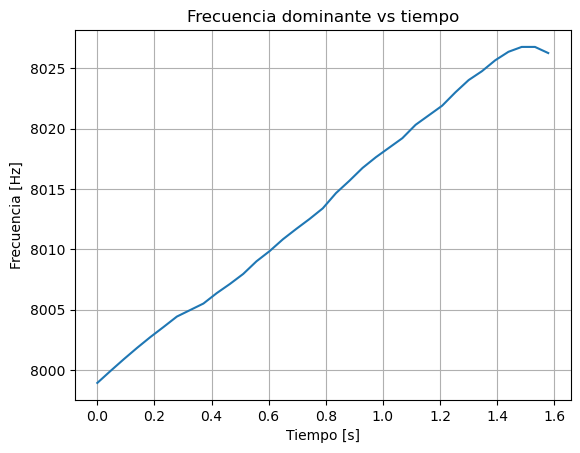

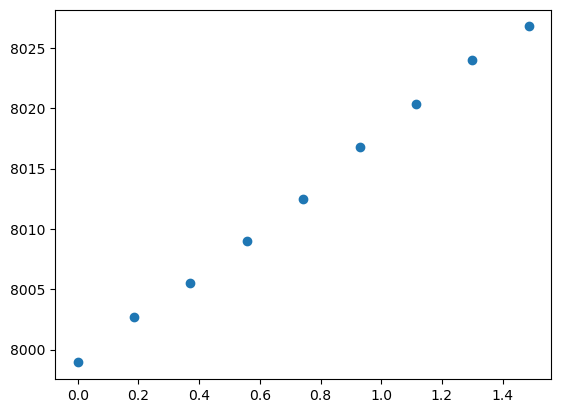

In [57]:
#código sacado en su mayoría desde https://github.com/librosa/librosa/blob/main/docs/tutorials/02-display/02-spectrogram.py,
#borré la mayor parte de comentarios en inglés. las partes hechas por mí tienen nombres y comentarios poco serios, pero respetenlo.
# %%
# .. _tutorial-display-spectrogram:
#
# Spectrograms
# ------------
# The :ref:`earlier sections <tutorial-intro-frequency>` of this tutorial demonstrate basic
# usage of the short-time Fourier transform (STFT), which can be useful for visualizing how
# the frequency content of a signal changes over time.
# This kind of visualization is known as a **spectrogram**, and you may have encountered
# this idea before.
# While spectrograms can be interpreted as *images* and displayed using `matplotlib`'s
# general-purpose image display functions (e.g. `matplotlib.pyplot.imshow`), there are several
# subtleties that can arise and it takes a bit of effort to get it right.
#
# As an example, let's create an STFT and display it using `imshow` directly.
# We'll first set up our imports and load an example file.

# sphinx_gallery_thumbnail_number = 6
from scipy.signal import medfilt, savgol_filter
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import HTML
ruta_acceso = r"C:\Users\A\OneDrive\Escritorio\tópicos\audios\prueba3_inclinacion2.wav"
srr = 22050
hop_lengthh = 1024
y, sr = librosa.load(ruta_acceso, sr = srr, offset=2.55, duration = 1.6) #sr = None para aumentar las muestras
print(sr)
#Si la frecuencia de muestreo es 44 100 muestras por cada segundo, puedo despejar el tiempo para el cual el código calculará las frecuencias
#y usarlo para determinar el armónico más fuerte del espectro, haciendo (indice * hop_length)/tasa_muestreo
# %%
# Now we can compute the STFT, create a figure, and call `imshow`.
# Note that when we call `imshow`, we have to convert the `stft` array from complex to real, or
# else it will fail due to a type mismatch.
resolucion = 8192
stft = librosa.stft(y, hop_length = hop_lengthh, n_fft = resolucion)
print(f"stft shape={stft.shape}")
#fig, ax = plt.subplots()
#ax.imshow(np.abs(stft))
#esta parte la hice yo, quizas se puede hacer más rápido con numpy pero usé lo que sabía perdoneme profe
t= np.zeros(stft.shape[1])
for i in range(0, stft.shape[1]):
    t[i] = (i*hop_lengthh)/srr    

#fig, ax = plt.subplots()
#librosa.display.specshow(stft, x_axis="time", y_axis="hz", vscale="dB")
fig, ax = plt.subplots()
img = librosa.display.specshow(stft, x_axis="time", y_axis="hz", vscale="dB", sr=srr, hop_length = hop_lengthh)
librosa.display.colorbar_db(img)
plt.savefig("Espectrograma_Carritoi2.pdf")
plt.show()
frecuencias = librosa.fft_frequencies(sr=srr, n_fft=resolucion)
frecuencias_absolutas = np.abs(stft) #por si acaso? me dijeron que lo haga
#ahora voy a filtrar un rango de frecuencia
frecuencias_filtradas = []
indices_frecuencias_filtradas = []
amplitudes_filtradas = []

for i in range(0, len(frecuencias)):
    if frecuencias[i]>=7900 and frecuencias[i]<=8100:
        frecuencias_filtradas.append(frecuencias[i])
        amplitudes_filtradas.append(frecuencias_absolutas[i, :])
        
#paso las listas a arreglos numpy para trabajarlos más fácil y que me compile el codigo
frecuencias_filtradas = np.array(frecuencias_filtradas)
amplitudes_filtradas = np.array(amplitudes_filtradas)
indices_frecuencias_filtradas = np.argmax(amplitudes_filtradas, axis=0)
f_dominante = frecuencias_filtradas[indices_frecuencias_filtradas]

f_dominante_promedio = medfilt(f_dominante, kernel_size=7) #esto lo hice con IA, se supone que filtra el ruido
indices_f_max = np.argmax(frecuencias_absolutas, axis=0) 
print(indices_f_max) #no muestra todos los indices pero elijo confiar? el np.argmax sin el axis=0 me devuelve un único valor (imagino que de todo el audio)
#esta parte si funciona pero hay código que no usamos realmente, son vestigios de codigos anteriores
no_se_si_funciona = frecuencias[indices_f_max]
print(no_se_si_funciona)

#un ajuste lineal para que los gráficos no se vean no continuos
f_continua = savgol_filter(f_dominante_promedio, window_length=11, polyorder=3) #esto lo hice con IA


largo_f_continua = len(f_continua)
print(largo_f_continua)

#extraigo una muestra para no graficar como 200 puntos de velocidad, la muestra ES representativa porque pasó por promedios y ajustes
f_continua_muestra = f_continua[0:largo_f_continua:4]
t_f_continua_muestra = t[0:largo_f_continua:4]


plt.plot(t, f_continua)
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia [Hz]")
plt.title("Frecuencia dominante vs tiempo")
plt.grid(True)
plt.savefig("Frecuencia_Dominante_Carritoi2.pdf")
plt.show()

plt.scatter(t_f_continua_muestra, f_continua_muestra)
plt.show()



#plt.plot(t_f_dom, f_dominante)
#plt.show()
#Ahora nos falta separar los gráficos y hacer una máscara AYUDAAAAAAA




#fig, ax = plt.subplots()
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB")
#librosa.display.colorbar_db(img)


#fig, ax = plt.subplots(nrows=2, sharex=True, height_ratios=[4, 1])
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB", ax=ax[0])
#librosa.display.colorbar_db(img)


#ax[0].legend(loc="upper right")
#ax[0].label_outer("ola")
#librosa.display.waveshow(y=y, sr=sr, ax=ax[1])



# Use the native sampling rate of the example by setting sr=None
#y, sr = librosa.loadx(ruta_acceso, sr=None)

# Use larger frames (4096 samples) to account for the higher sampling rate
# Use a smaller hop length to get a higher time resolution in the stft
#stft = librosa.stft(y, n_fft=8192, hop_length=256)
#print(f"stft shape={stft.shape}")

# %%
# Now we can supply our analysis parameters to `specshow` so that axes are constructed
# properly.
# While we're at it, we can also change the threshold for decibel scaling by setting `top_db`
# (which defaults to 80, but let's set it to 60 to suppress low-amplitude noise).
# Finally, we can choose a different colormap for sequential data by setting `cmap_seq=`.
# Here we'll use a black-on-white colormap, suitable for print media.

#fig, ax = plt.subplots()
#img = librosa.display.specshow(stft, x_axis="time", y_axis="log", vscale="dB",
                              # sr=sr, hop_length=256, top_db=60,
                               #cmap_seq="gray_r")
#librosa.display.colorbar_db(img)

# %%
# Summary and tips
# ----------------
# We've really only scratched the surface when it comes to the functionality provided by
# `specshow`, and the subsequent sections in this tutorial will dig into the details.
#
# A few things that can be helpful to keep in mind:
#   - The most important parameters are `x_axis` and `y_axis`.  Most of the remaining
#     parameters are there to support unit conversion for different axis scalings.
#   - There is nothing special about the orientation here: any axis can be a time axis or a
#     frequency axis.  This makes it easy to draw sideways spectrograms, time-by-time plots,
#     frequency-by-frequency plots, etc.  The section on :ref:`non-spectral <tutorial-display-nonspectral>`
#     data visualization provides some examples of this.
#   - The underlying display object is generated by `matplotlib.pyplot.pcolormesh`.  Any
#     parameters acceptable to `pcolormesh` can be passed into `specshow` as well.





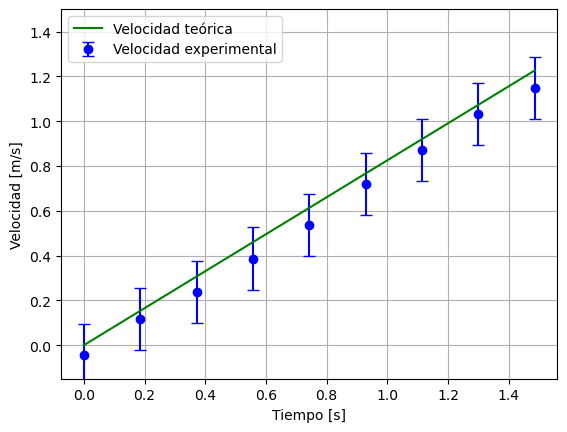

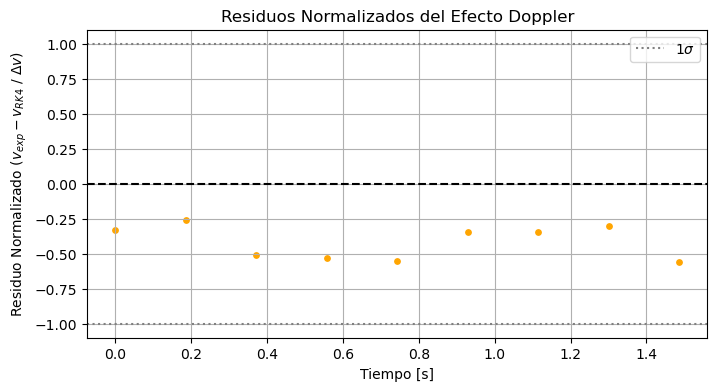

In [58]:
#Ahora programo las formulas del efecto doppler
h_1 = 0.097
h_2 = 0.175
Largo = 2.08
g=9.81

T = 273.15+20.1 
V_sonido = np.sqrt((1.4*8.314*T)/0.029)
f_emitida = 8000
velocidades_receptor = np.zeros(len(f_continua_muestra))
for i in range(len(f_continua_muestra)):
    v_r = V_sonido*((f_continua_muestra/f_emitida)-1) #porque es un arreglo de numpy (debería funcionar)


velocidad_teórica = t_f_continua_muestra*(h_2/Largo)*g

#análisis de error propagado en la velocidad
import numpy as np
error_termometro = 1
error_Hz_recibido = srr/resolucion
dv_vs = (f_continua_muestra/f_emitida)-1
dv_fr = V_sonido*(1/f_emitida)
dv_fe = V_sonido*(-(f_continua_muestra/f_emitida**2))
error_v_sonido = 0.5*np.abs((1/(np.sqrt(T)))*np.sqrt(1.4*8.314/0.029))*error_termometro
error_velocidad = np.sqrt((dv_vs*error_v_sonido)**2+(dv_fr*error_Hz_recibido)**2+(dv_fe*error_f_rep)**2) 

#residuos normalizados 

residuos_normalizados = (v_r-velocidad_teórica)/error_velocidad
plt.errorbar(t_f_continua_muestra, v_r, yerr=error_velocidad, fmt="o", capsize =4, color="blue", label="Velocidad experimental")
plt.plot(t_f_continua_muestra, velocidad_teórica, color="green", label="Velocidad teórica")
plt.ylim((-0.15, 1.5))
plt.ylabel("Velocidad [m/s]")
plt.xlabel("Tiempo [s]")
plt.grid(True)
plt.legend()
plt.savefig("Comparacion_Velocidad_carritoi2.pdf")
plt.show()

plt.figure(figsize=(8, 4))
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='gray', linestyle=':', label=r'$1\sigma$')
plt.axhline(-1, color='gray', linestyle=':')

plt.scatter(t_f_continua_muestra, residuos_normalizados, color='orange', s=15)
plt.xlabel("Tiempo [s]")
plt.ylabel(r"Residuo Normalizado ($v_{exp} - v_{RK4}$ / $\Delta v$)")
plt.title("Residuos Normalizados del Efecto Doppler")
plt.legend()
plt.grid(True)
plt.savefig("ResiduosN_carritoi2.pdf")
plt.show()

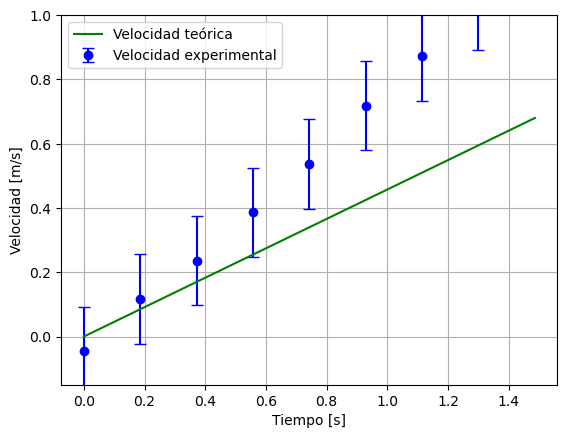

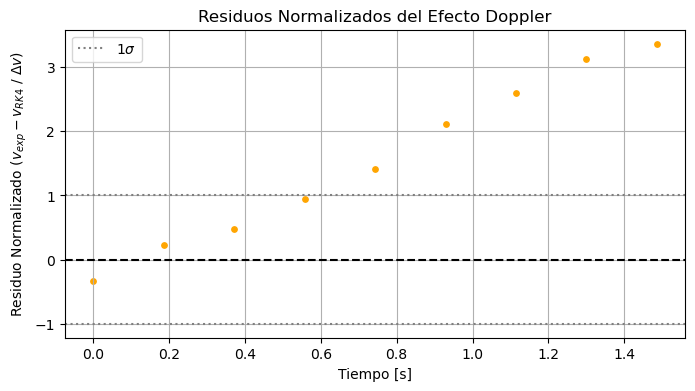

In [59]:
#Ahora programo las formulas del efecto doppler
h_1 = 0.097
h_2 = 0.175
Largo = 2.08
g=9.81

T = 273.15+20.1 
V_sonido = np.sqrt((1.4*8.314*T)/0.029)
f_emitida = 8000
velocidades_receptor = np.zeros(len(f_continua_muestra))
for i in range(len(f_continua_muestra)):
    v_r = V_sonido*((f_continua_muestra/f_emitida)-1) #porque es un arreglo de numpy (debería funcionar)


velocidad_teórica = t_f_continua_muestra*(h_1/Largo)*g

#análisis de error propagado en la velocidad
import numpy as np
error_termometro = 1
error_Hz_recibido = srr/resolucion
dv_vs = (f_continua_muestra/f_emitida)-1
dv_fr = V_sonido*(1/f_emitida)
dv_fe = V_sonido*(-(f_continua_muestra/f_emitida**2))
error_v_sonido = 0.5*np.abs((1/(np.sqrt(T)))*np.sqrt(1.4*8.314/0.029))*error_termometro
error_velocidad = np.sqrt((dv_vs*error_v_sonido)**2+(dv_fr*error_Hz_recibido)**2+(dv_fe*error_f_rep)**2) 

#residuos normalizados 

residuos_normalizados = (v_r-velocidad_teórica)/error_velocidad
plt.errorbar(t_f_continua_muestra, v_r, yerr=error_velocidad, fmt="o", capsize =4, color="blue", label="Velocidad experimental")
plt.plot(t_f_continua_muestra, velocidad_teórica, color="green", label="Velocidad teórica")
plt.ylim((-0.15, 1.0))
plt.ylabel("Velocidad [m/s]")
plt.xlabel("Tiempo [s]")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='gray', linestyle=':', label=r'$1\sigma$')
plt.axhline(-1, color='gray', linestyle=':')

plt.scatter(t_f_continua_muestra, residuos_normalizados, color='orange', s=15)
plt.xlabel("Tiempo [s]")
plt.ylabel(r"Residuo Normalizado ($v_{exp} - v_{RK4}$ / $\Delta v$)")
plt.title("Residuos Normalizados del Efecto Doppler")
plt.legend()
plt.grid(True)
plt.show()